# 1. EDA & Feature Engineering — College Cutoff Predictor

**Dataset:** `kaggle_pivot_min_descending.csv` — Maharashtra engineering college admission cutoffs (MHT-CET / JEE(Main) / Merit), pivoted by college, seat category (`seat_type`) and `branch`.

**Goal of this notebook:**
1. Explore the data and understand distributions/relationships
2. Identify and remove data leakage
3. Engineer features and build a preprocessing pipeline
4. Split into train/test and persist artifacts for the model-training stage

**Target variable:** `min` — the minimum percentile a candidate needed to get admission for a given (college, score_type, seat_type, branch) combination. This is the number a student really wants predicted: *"what percentile do I need for X college, Y branch, Z category?"*


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

%matplotlib inline


## 2. Load the Dataset

In [2]:
df = pd.read_csv('data/kaggle_pivot_min_descending.csv')
df.head()


,college_name,score_type,seat_type,branch,sum,count,max,min,mean,max-min,max-mean
0,Veermata Jijabai Technological Institute(VJTI)...,MHT-CET,TFWS,Computer Engineering,299.638141,3,99.913236,99.843394,99.879380,0.069842,0.033856
1,Veermata Jijabai Technological Institute(VJTI)...,MHT-CET,LOPENS,Computer Engineering,699.371128,7,100.000000,99.829843,99.910161,0.170156,0.089839
2,Veermata Jijabai Technological Institute(VJTI)...,MHT-CET,GOPENS,Computer Engineering,1698.390955,17,99.995273,99.817615,99.905350,0.177659,0.089923
3,COEP Technological University,MHT-CET,GNT3S,Computer Engineering,99.803612,1,99.803612,99.803612,99.803612,0.000000,0.000000
4,COEP Technological University,MHT-CET,LNT2S,Computer Engineering,99.787304,1,99.787304,99.787304,99.787304,0.000000,0.000000


In [3]:
print("Shape:", df.shape)
df.info()


Shape: (28377, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28377 entries, 0 to 28376
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   college_name  28377 non-null  object 
 1   score_type    28377 non-null  object 
 2   seat_type     28377 non-null  object 
 3   branch        28377 non-null  object 
 4   sum           28377 non-null  float64
 5   count         28377 non-null  int64  
 6   max           28377 non-null  float64
 7   min           28377 non-null  float64
 8   mean          28377 non-null  float64
 9   max-min       28377 non-null  float64
 10  max-mean      28377 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 2.4+ MB


## 3. Data Quality Checks

Check for missing values and duplicate rows before doing anything else.

In [4]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
college_name    0
score_type      0
seat_type       0
branch          0
sum             0
count           0
max             0
min             0
mean            0
max-min         0
max-mean        0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


No missing values and no duplicate rows in this dataset — one less thing to clean.

## 4. Statistical Summary

In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
sum,28377.0,233.107703,451.505203,0.004739,48.141988,84.382602,242.888443,9076.725302
count,28377.0,3.677098,5.807874,1.000000,1.000000,2.000000,4.000000,92.000000
max,28377.0,59.974110,26.164252,0.004739,41.187314,64.060928,81.973434,100.000000
min,28377.0,52.102999,28.700460,0.004739,26.900779,55.218152,76.990020,99.843394
mean,28377.0,55.774946,26.526845,0.004739,34.329932,58.566008,78.391101,99.910161
max-min,28377.0,7.871111,14.426868,0.000000,0.000000,0.060330,9.184018,95.862237
max-mean,28377.0,4.199164,7.838619,0.000000,0.000000,0.028206,4.882322,66.975427


## 5. Categorical Column Cardinality

Understanding how many unique values each categorical column has is critical — it decides our encoding strategy later.

In [7]:
categorical_cols = ['college_name', 'score_type', 'seat_type', 'branch']

for col in categorical_cols:
    print(f"{col:15s}: {df[col].nunique():4d} unique values")


college_name   :  326 unique values
score_type     :    3 unique values
seat_type      :   77 unique values
branch         :   95 unique values


326 colleges and 95 branches is high cardinality — a plain one-hot encode of everything will create a very wide, sparse matrix. We'll handle this with **rare-category grouping** in the feature engineering section below.

## 6. Univariate Analysis — `score_type`

In [8]:
df['score_type'].value_counts()


score_type
MHT-CET      26622
JEE(Main)     1540
Merit          215
Name: count, dtype: int64

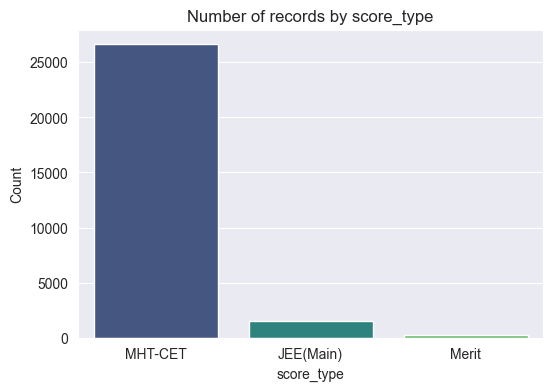

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='score_type', order=df['score_type'].value_counts().index, palette='viridis')
plt.title('Number of records by score_type')
plt.ylabel('Count')
plt.show()


The dataset is dominated by **MHT-CET** (~94% of rows), with JEE(Main) and Merit-based entries being a small minority. Keep this imbalance in mind when interpreting model performance later.

## 7. Univariate Analysis — `seat_type`

In [10]:
top_seat_types = df['seat_type'].value_counts().head(20)
top_seat_types


seat_type
AI          1560
GOPENH      1330
EWS         1239
LOPENH      1219
GOPENO      1197
LOPENO      1089
TFWS        1082
DEFOPENS    1047
GOBCH        830
PWDOPENH     820
LOBCH        815
GSCH         805
GNT1H        794
GNT2H        776
GOBCO        775
GSCO         746
LSCH         743
GSTH         739
GVJH         706
GNT3H        689
Name: count, dtype: int64

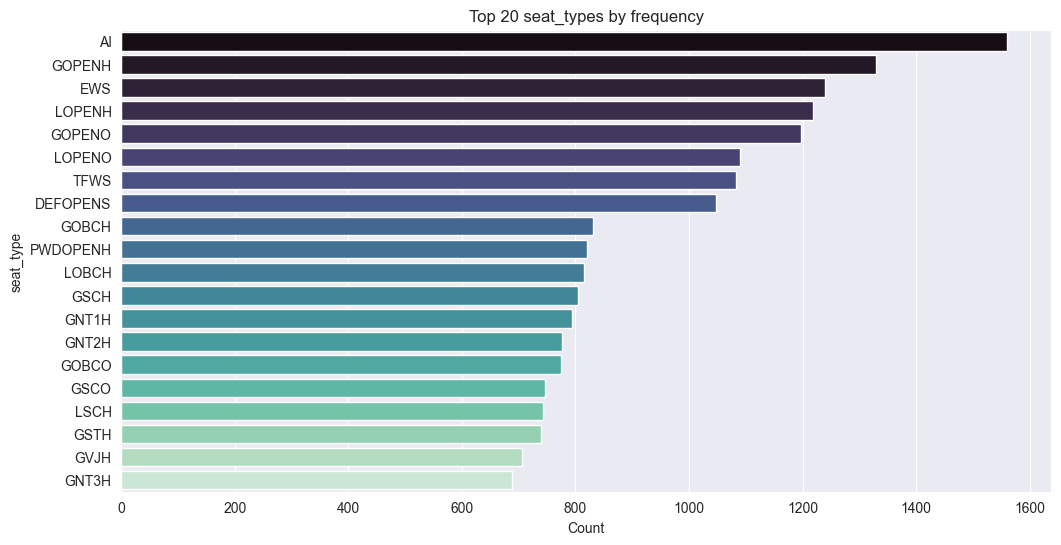

In [11]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_seat_types.values, y=top_seat_types.index, palette='mako')
plt.title('Top 20 seat_types by frequency')
plt.xlabel('Count')
plt.show()


## 8. Univariate Analysis — `branch`

In [12]:
top_branches = df['branch'].value_counts().head(15)
top_branches


branch
Computer Engineering                                                              4512
Electronics and Telecommunication Engg                                            4299
Mechanical Engineering                                                            3235
Computer Science and Engineering                                                  2664
Electrical Engineering                                                            2587
Information Technology                                                            2500
Civil Engineering                                                                 2275
Artificial Intelligence and Data Science                                          1130
Computer Science and Engineering(Artificial Intelligence and Machine Learning)     559
Chemical Engineering                                                               459
Artificial Intelligence (AI) and Data Science                                      344
Electronics and Computer Engineering

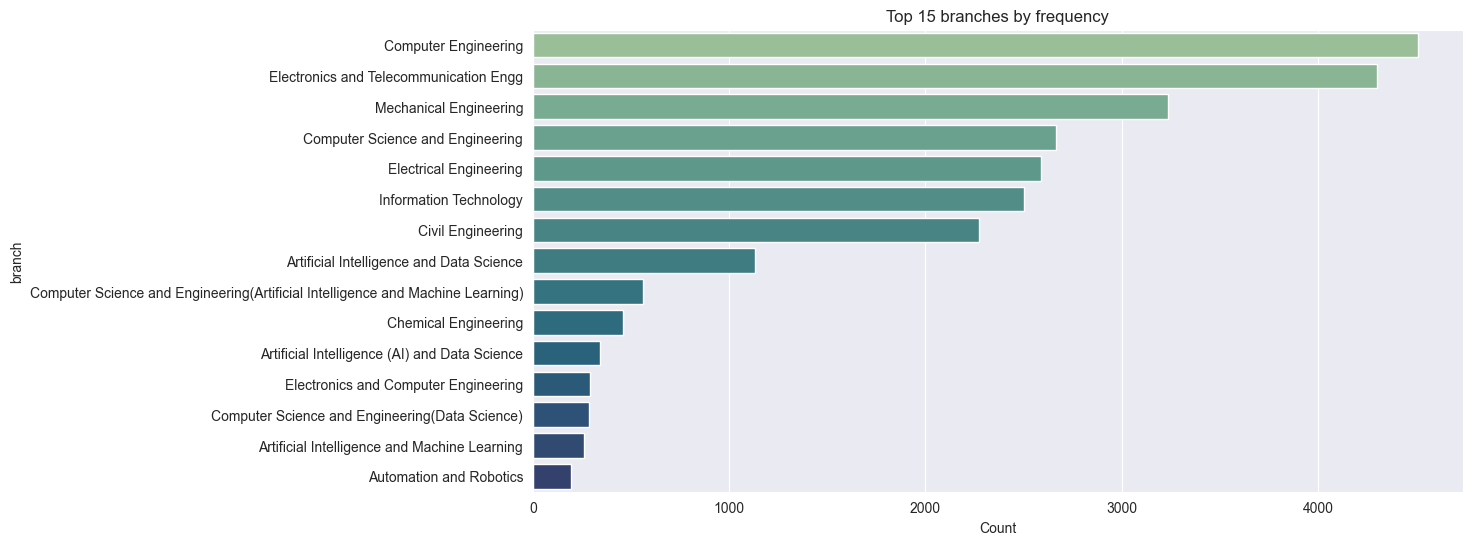

In [13]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_branches.values, y=top_branches.index, palette='crest')
plt.title('Top 15 branches by frequency')
plt.xlabel('Count')
plt.show()


**Computer Engineering**, **Electronics & Telecommunication**, and **Mechanical Engineering** dominate the branch list, as expected for Maharashtra engineering admissions.

## 9. Univariate Analysis — `college_name`

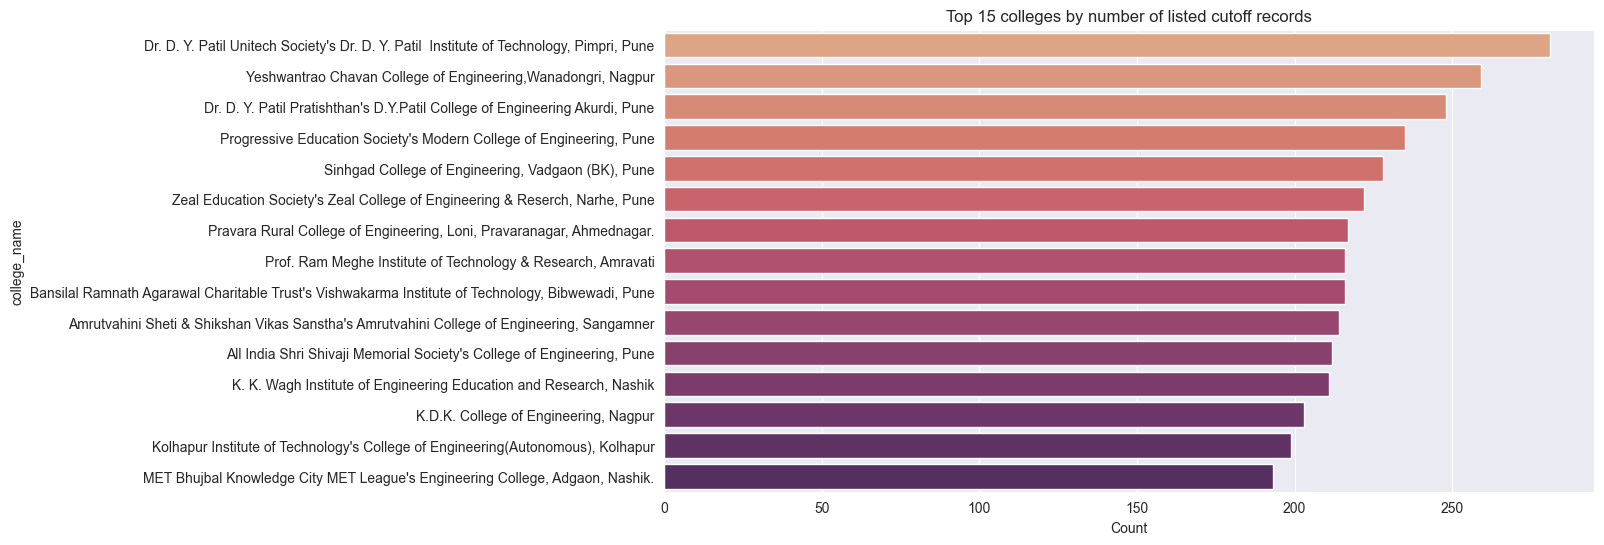

In [14]:
top_colleges = df['college_name'].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=top_colleges.values, y=top_colleges.index, palette='flare')
plt.title('Top 15 colleges by number of listed cutoff records')
plt.xlabel('Count')
plt.show()


## 10. Target Variable Analysis — `min`

This is what we ultimately want to predict.

In [15]:
print(df['min'].describe())
print("\nSkewness:", df['min'].skew())


count    28377.000000
mean        52.102999
std         28.700460
min          0.004739
25%         26.900779
50%         55.218152
75%         76.990020
max         99.843394
Name: min, dtype: float64

Skewness: -0.19927394098379586


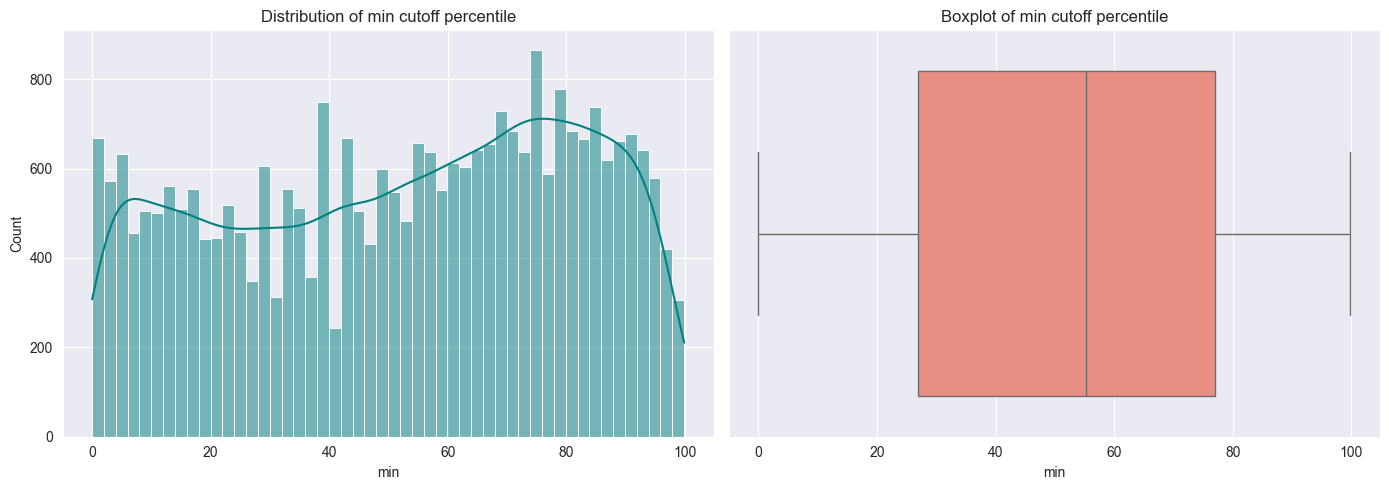

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df['min'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of min cutoff percentile')

sns.boxplot(x=df['min'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of min cutoff percentile')

plt.tight_layout()
plt.show()


`min` has a skew of about **-0.20** — nearly symmetric, so we don't need a log transform on the target. Most cutoffs cluster in the higher percentile range, with a longer tail toward lower percentiles (less competitive seats).

## 11. Bivariate Analysis — `min` vs `score_type`

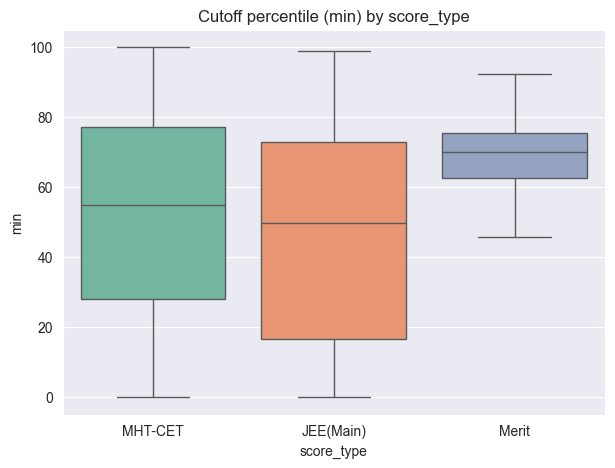

In [17]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='score_type', y='min', palette='Set2')
plt.title('Cutoff percentile (min) by score_type')
plt.show()


## 12. Bivariate Analysis — `min` vs `seat_type` (common categories)

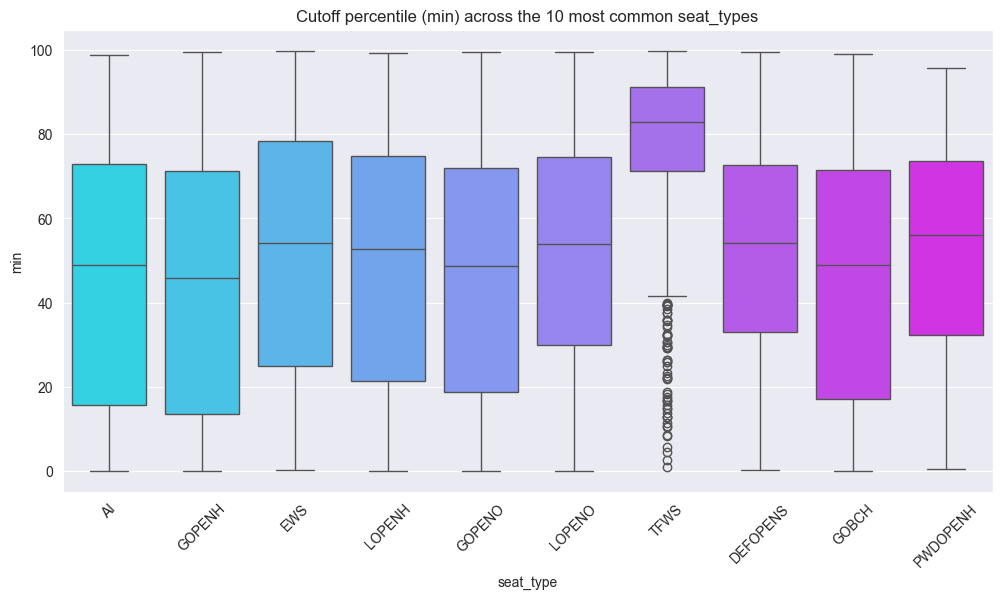

In [18]:
common_seat_types = df['seat_type'].value_counts().head(10).index
subset = df[df['seat_type'].isin(common_seat_types)]

plt.figure(figsize=(12,6))
sns.boxplot(data=subset, x='seat_type', y='min', order=common_seat_types, palette='cool')
plt.xticks(rotation=45)
plt.title('Cutoff percentile (min) across the 10 most common seat_types')
plt.show()


Seat category clearly shifts the cutoff distribution — reserved/relaxed categories (e.g. `TFWS`, `EWS`, various `GOBC*`/`GNT*` categories) sit at noticeably different percentile ranges than general open categories. This confirms `seat_type` is an important predictive feature.

## 13. Correlation Analysis & Data Leakage Check

`max`, `mean`, `sum`, `max-min`, and `max-mean` are **all mathematically derived using `min`** (they come from the same pivot aggregation). Using them as model features would leak the answer into the input — the model would just learn algebra, not make a genuine prediction. Let's confirm this with a correlation heatmap, then drop them.

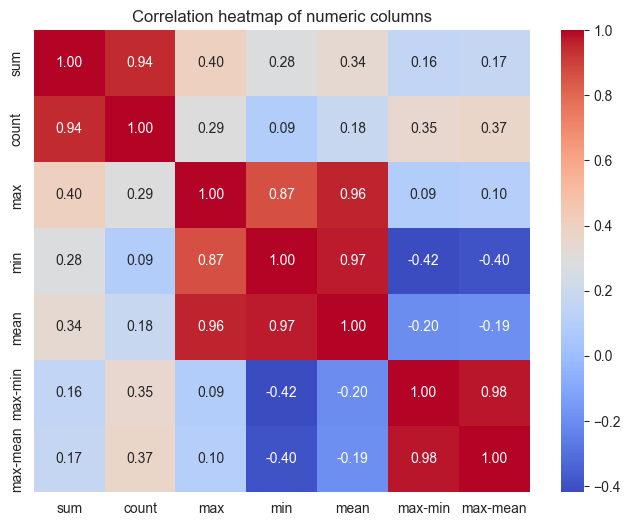

In [19]:
numeric_cols = ['sum', 'count', 'max', 'min', 'mean', 'max-min', 'max-mean']

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap of numeric columns')
plt.show()


As expected, `max` (0.87) and `mean` (0.97) are extremely highly correlated with `min` — textbook leakage. `count` (0.09) has a weak, legitimate relationship with `min` (how many seats/candidates were counted in that combination) and is safe to keep as a feature.

## 14. Outlier Check — `count`

Skewness of count: 5.848278568319374


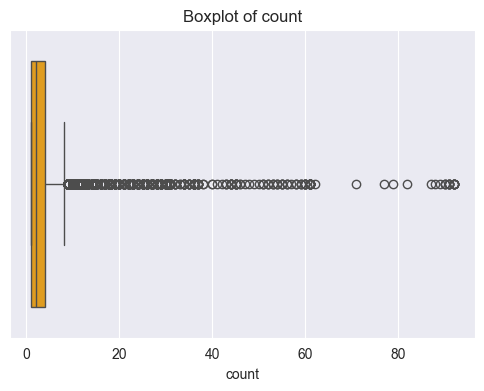

In [20]:
print("Skewness of count:", df['count'].skew())

plt.figure(figsize=(6,4))
sns.boxplot(x=df['count'], color='orange')
plt.title('Boxplot of count')
plt.show()


`count` is heavily right-skewed (skew ≈ 5.8) with some large outliers (colleges/branches with many recorded candidates). We won't remove these rows — they're valid, just skewed — but we will **scale** `count` in the preprocessing pipeline so it doesn't dominate distance-based models.

---
# Feature Engineering

Plan:
1. **Drop leakage columns**: `sum`, `max`, `mean`, `max-min`, `max-mean`
2. **Reduce cardinality** of `college_name`, `branch`, `seat_type` by grouping rare categories into `'Other'`
3. **Train/test split**
4. **Build a preprocessing pipeline**: One-Hot Encode categoricals + scale `count`
5. **Persist** `train.csv`, `test.csv`, and `preprocessor.pkl` to `artifacts/`


## 15. Drop Leakage Columns

In [21]:
df_model = df.drop(columns=['sum', 'max', 'mean', 'max-min', 'max-mean'])
df_model.head()


,college_name,score_type,seat_type,branch,count,min
0,Veermata Jijabai Technological Institute(VJTI)...,MHT-CET,TFWS,Computer Engineering,3,99.843394
1,Veermata Jijabai Technological Institute(VJTI)...,MHT-CET,LOPENS,Computer Engineering,7,99.829843
2,Veermata Jijabai Technological Institute(VJTI)...,MHT-CET,GOPENS,Computer Engineering,17,99.817615
3,COEP Technological University,MHT-CET,GNT3S,Computer Engineering,1,99.803612
4,COEP Technological University,MHT-CET,LNT2S,Computer Engineering,1,99.787304


## 16. Reduce Cardinality (Rare-Category Grouping)

- `branch`: 21 of 95 branches occur fewer than 10 times → group into `'Other'`
- `seat_type`: 13 of 77 seat_types occur fewer than 10 times → group into `'Other'`
- `college_name`: only 2 of 326 colleges occur fewer than 5 times → group those into `'Other'` too, just for consistency


In [22]:
def group_rare_categories(series, threshold):
    """Replace categories occurring fewer than `threshold` times with 'Other'."""
    counts = series.value_counts()
    rare_labels = counts[counts < threshold].index
    return series.apply(lambda x: 'Other' if x in rare_labels else x)

df_model['branch'] = group_rare_categories(df_model['branch'], threshold=10)
df_model['seat_type'] = group_rare_categories(df_model['seat_type'], threshold=10)
df_model['college_name'] = group_rare_categories(df_model['college_name'], threshold=5)

print("branch unique:", df_model['branch'].nunique())
print("seat_type unique:", df_model['seat_type'].nunique())
print("college_name unique:", df_model['college_name'].nunique())


branch unique: 75
seat_type unique: 65
college_name unique: 326


**Note on `college_name`:** grouping barely changes its cardinality (326 → still high) since almost every college is well represented. That's fine — if you plan to use **CatBoost** for modeling (recommended, given tree-based models handle high-cardinality categoricals natively and you already have a `catboost_info/` folder in your project), you can skip one-hot encoding `college_name`/`branch` entirely and pass them as raw categorical features. The sklearn `OneHotEncoder` pipeline below is shown as the general-purpose approach that also works for linear/other models.

## 17. Save the Processed Dataset

This notebook's job stops here: explore the data, remove leakage, and hand off a **clean, feature-engineered CSV**. Splitting into train/test, encoding, scaling, and model training are handled downstream by `src/components/data_ingestion.py`, `data_transformation.py`, and `model_trainer.py` — keeping one source of truth for those steps instead of duplicating them here.

In [23]:
os.makedirs('data', exist_ok=True)
df_model.to_csv('data/college_cutoff_processed.csv', index=False)
print("Saved notebook/data/college_cutoff_processed.csv")


Saved notebook/data/college_cutoff_processed.csv


---
## Summary

| Step | Outcome |
|---|---|
| Missing values / duplicates | None found |
| Leakage columns removed | `sum`, `max`, `mean`, `max-min`, `max-mean` |
| Kept columns | `college_name`, `score_type`, `seat_type`, `branch`, `count`, `min` (target) |
| Cardinality reduction | Rare categories (`branch` < 10, `seat_type` < 10, `college_name` < 5) grouped into `'Other'` |
| Output | `notebook/data/college_cutoff_processed.csv` |

**Next step:** run the production pipeline —

```
python src/components/data_ingestion.py
```

which chains `DataIngestion` (reads `college_cutoff_processed.csv`, does the train/test split, saves raw/train/test CSVs to `artifacts/`) → `DataTransformation` (builds and saves `preprocessor.pkl`, one-hot encodes categoricals + scales `count`) → `ModelTrainer` (grid-searches regression models, saves the best as `artifacts/model.pkl`, prints the final R² score).
